## Restart workflow: the checkpoint lifecycle end to end

Every production run eventually needs the full checkpoint lifecycle: record the
configuration next to the data, run, get interrupted, restore *exactly*, continue -- and
sometimes continue with deliberately changed parameters. This notebook walks the whole
cycle on a small forced 2D run (forced, so the stochastic-forcing state has to
round-trip too):

1. **`params.save(snap_path)`** -- what `params.json` records, and its safety semantics;
2. an uninterrupted **reference run A** ($t: 0 \to 10$);
3. **run B**, "interrupted" at $t = 5$, then restored with
   `Parameters.from_snapshot` + `get_saved_steps` + `load_snapshot` and continued to
   $t = 10$;
4. verification that A and B end **bitwise identical** -- the checkpoint carries the
   complete state, including the forcing RNG key;
5. a **parameter-override restart** (run C: same data, stronger dissipation, new
   directory);
6. the checkpointing invariants worth knowing (`docs/checkpointing.md`).

In [1]:
#imports
import os, shutil, json
import jax
import jax.numpy as jnp
import jax.numpy.fft as ft
import matplotlib.pyplot as plt

import jax_rmhd as jr
import jax_rmhd.snapshot_io as sn
import jax_rmhd.diagnostics as diag

base = "data/restart-workflow/"
runA, runB, runC = base + "runA/", base + "runB/", base + "runC/"
#start fresh on re-run: snapshot numbering continues from whatever is on disk, and
#params.json is sticky, so stale directories would change what this notebook demonstrates
if os.path.isdir(base):
    shutil.rmtree(base)

jax is using 32bit precision.


In [2]:
nsnap = 1000
t_snap = 1.0

def make_params(**overrides):
    #the run configuration in one place; identical on every call unless overridden
    kwargs = dict(nx=128, ny=128, Lx=2.0 * jnp.pi, Ly=2.0 * jnp.pi, diss=(1e-9, 1e-9),
                  hyper=3, cfl_safety=0.5, dims=2,
                  forcing=True, forcing_mode="elsasser",
                  forcing_power_elsasser=(0.15, 0.15), forcing_tau=1.0, fshell=(1, 3),
                  forcing_seed=234, forcing_scale_max=1.0)
    kwargs.update(overrides)
    return jr.Parameters(**kwargs)

def zero_init(x, y):
    return jnp.zeros((2,) + jnp.broadcast_shapes(x.shape, y.shape))

### 1. `params.save`: recording how a run directory was made

`params.save(snap_path)` writes `params.json`: the exact **constructor arguments** of
the `Parameters` object (not derived attributes), plus the floating-point precision.
It is an explicit call -- nothing writes `params.json` automatically -- and it is
designed to be safe to call repeatedly:

- saving an **identical** record again is a silent no-op;
- saving a **different** record over an existing one is a **hard error**: a run
  directory documents one configuration, forever. If a change really is intended, you
  delete the file and re-save (or save into a new directory, as run C does below).

Under MPI the call is collective (rank 0 checks/writes, the outcome is broadcast) --
never call it from a subset of ranks.

In [3]:
params_a = make_params()

params_a.save(runA)  #first save: writes runA/params.json
print("params.json records the constructor arguments + precision:\n")
print(json.dumps(json.load(open(runA + "params.json")), indent=1))

params_a.save(runA)  #identical re-save: silently a no-op
print("\nidentical re-save: no error, nothing rewritten")

#saving a DIFFERENT record into the same directory is a hard error
try:
    make_params(diss=(1e-5, 1e-5)).save(runA)
except ValueError as e:
    print("\ndiffering record -> ValueError:\n  " + str(e))

params.json records the constructor arguments + precision:

{
 "nx": 128,
 "ny": 128,
 "Lx": 6.283185307179586,
 "Ly": 6.283185307179586,
 "diss": [
  1e-09,
  1e-09
 ],
 "hyper": 3,
 "cfl_safety": 0.5,
 "dt": 0.1,
 "adaptive_timestep": true,
 "dims": 2,
 "nz": 1,
 "Lz": 0.0,
 "z_diss": 0.25,
 "z_diss_hyper": 2.0,
 "z_diff_order": 4,
 "eqtype": "RMHD",
 "forcing": true,
 "forcing_mode": "elsasser",
 "forcing_power": 1.0,
 "forcing_power_elsasser": [
  0.3,
  0.3
 ],
 "forcing_tau": 1.0,
 "fshell": [
  1,
  3
 ],
 "forcing_seed": 234,
 "forcing_scale_max": 1.0,
 "forcing_norm_per_step": true,
 "lsrk_scan": true,
 "forcing_shell_noise": false,
 "comm_backend": "mpi4jax",
 "cfl_every": 1,
 "_precision": "32",
 "_created": "2026-07-30 18:34:03"
}

identical re-save: no error, nothing rewritten

differing record -> ValueError:
  data/restart-workflow/runA/params.json already records different parameters (saved, current): {'diss': ([1e-09, 1e-09], [1e-05, 1e-05])}. If the change is intended,

### 2. Reference run A: $t = 0 \to 10$, uninterrupted

One detail matters for the bitwise comparison later: `simulate_scan` advances in jitted
blocks of `nblock` steps, so we compute `NBLOCK` **once** (from the fresh state) and
reuse that same integer for **every** `simulate_scan` call in this notebook. Identical
block boundaries make the step sequence -- and hence the trajectory -- exactly
reproducible between the uninterrupted run and the restarted one.

In [4]:
mngr_a = jr.snapshot_manager_setup(params=params_a, snap_path=runA, nsnap=nsnap)
kgrid_a = jr.setup_kgrids(params_a)
state = jr.initialize(zero_init, params_a)

NBLOCK = jr.estimate_good_nblock(state, kgrid_a, params_a, t_snap, 10.0, nblock_min=10)
print("NBLOCK =", NBLOCK)

#buffer donation: `state` is consumed by simulate_scan -- use the returned end_a
end_a = jr.simulate_scan(state, kgrid_a, params_a, NBLOCK, t_snap=t_snap, t_end=10.0,
                         mngr=mngr_a, save=True, print_every=10)

NBLOCK = 10


Saving initial state as snapshot 0


Saving snapshot 1
1.0568179


1.5740491
2.0191247
Saving snapshot 2


2.4604943


...

7.769638
8.126094
Saving snapshot 8


8.516378
8.900317


Saving snapshot 9
9.2732725


9.602515


9.94998
Saving final state as snapshot 10
Ending simulation at t = 10.0149555. It took 6.968191461997776s


### 3. Run B: identical setup, "interrupted" at $t = 5$

Same parameters, same seed, own directory. We simply stop at `t_end=5.0` -- as far as
the on-disk state is concerned, this is indistinguishable from a job that died after its
last checkpoint.

In [5]:
params_b1 = make_params()  #identical parameters, identical seed
params_b1.save(runB)
mngr_b1 = jr.snapshot_manager_setup(params=params_b1, snap_path=runB, nsnap=nsnap)
kgrid_b1 = jr.setup_kgrids(params_b1)  #rebuild: one kgrid per Parameters object
state = jr.initialize(zero_init, params_b1)
mid_b = jr.simulate_scan(state, kgrid_b1, params_b1, NBLOCK, t_snap=t_snap, t_end=5.0,
                         mngr=mngr_b1, save=True, print_every=10)
print("run B 'interrupted' at t =", float(mid_b.t))

Saving initial state as snapshot 0


Saving snapshot 1
1.0568179


1.5740491
2.0191247
Saving snapshot 2


2.4604943
2.8503008


Saving snapshot 3
3.232981


3.6095011


3.937561
Saving snapshot 4


4.2246337


4.5788674
4.982119


Saving final state as snapshot 5
Ending simulation at t = 5.0195804. It took 3.9144984599988675s
run B 'interrupted' at t = 5.019580364227295


### The restore pattern

Pretend this is a fresh session (a new job submission after the old one died). The
pattern every restart uses:

1. `params = jr.Parameters.from_snapshot(snap_path)` -- re-runs `__init__` from the
   recorded `params.json` (explicit overrides win; unknown keys warn; a precision
   mismatch warns);
2. `steps = sn.get_saved_steps(snap_path)` -- enumerate what's on disk (**not**
   `mngr.all_steps()`, which misreads per-rank layouts);
3. `state = sn.load_snapshot(steps[-1], snap_path, params)` -- a *read*, which never
   constructs a `CheckpointManager` internally (manager restores barrier and can
   deadlock under MPI when ranks read different directories);
4. `snapshot_manager_setup` on the **same** path for the continued writing -- snapshot
   numbering continues automatically from `max(get_saved_steps(...)) + 1`, so the new
   snapshots slot in after the old ones;
5. `simulate_scan(state, ..., t_end=10.0)` with the **same `NBLOCK`**.

In [6]:
#(1) reconstruct Parameters from the directory's own record
params_b = jr.Parameters.from_snapshot(runB)
kgrid_b = jr.setup_kgrids(params_b)

#(2) enumerate what's on disk -- get_saved_steps, never mngr.all_steps()
steps_b = sn.get_saved_steps(runB)
print("saved steps in runB:", steps_b)

#(3) load the latest snapshot (a read: no CheckpointManager constructed)
state = sn.load_snapshot(steps_b[-1], runB, params_b)
print(f"restored snapshot {steps_b[-1]} at t = {float(state.t):.4f}")
print("forcing_scale restored:", state.forcing_scale)

#(4) a manager on the SAME path for continued writing;
#    snapshot numbering continues from max(get_saved_steps(...)) + 1 automatically
mngr_b = jr.snapshot_manager_setup(params=params_b, snap_path=runB, nsnap=nsnap)

#(5) continue with the SAME NBLOCK.
#Buffer-donation gotcha: the loaded `state` is CONSUMED by simulate_scan (touching it
#afterwards raises "Array has been deleted") -- if you need it again, reload it.
end_b = jr.simulate_scan(state, kgrid_b, params_b, NBLOCK, t_snap=t_snap, t_end=10.0,
                         mngr=mngr_b, save=True, print_every=10)

saved steps in runB: [0, 1, 2, 3, 4, 5]
restored snapshot 5 at t = 5.0196
forcing_scale restored: [-0.06025923  0.05867143]


Saving initial state as snapshot 6


5.409079
5.8427653


Saving snapshot 7
6.287036


6.7078357
Saving snapshot 8


...

7.8031564
Saving snapshot 9


8.166407
8.553576


8.942621
Saving snapshot 10


9.308288
9.636506


9.981993
Saving final state as snapshot 11
Ending simulation at t = 10.0149555. It took 3.7466479600007006s


### 4. Continuity verification: bitwise agreement

Run A went $0 \to 10$ in one piece; run B went $0 \to 5$, was restored from disk, and
went $5 \to 10$. Because the checkpoint carries the **full** `SimulationState` --
fields, OU `forcing_state`, the RNG `forcing_key`, and the per-step `forcing_scale` --
and both runs execute the identical block-of-`NBLOCK`-steps sequence, the two end states
should agree not just closely but **bitwise**.

In [7]:
t_diff = float(jnp.abs(end_a.t - end_b.t))
fields_diff = float(jnp.max(jnp.abs(end_a.fields - end_b.fields)))
forcing_state_diff = float(jnp.max(jnp.abs(end_a.forcing_state - end_b.forcing_state)))
forcing_scale_diff = float(jnp.max(jnp.abs(end_a.forcing_scale - end_b.forcing_scale)))
key_match = bool(jnp.array_equal(jax.random.key_data(end_a.forcing_key),
                                 jax.random.key_data(end_b.forcing_key)))

print(f"  t:                A = {float(end_a.t):.6f}, B = {float(end_b.t):.6f}, diff = {t_diff:.3e}")
print(f"  fields        max abs diff: {fields_diff:.3e}")
print(f"  forcing_state max abs diff: {forcing_state_diff:.3e}")
print(f"  forcing_scale max abs diff: {forcing_scale_diff:.3e}")
print(f"  forcing_key matches:        {key_match}")

ok = (t_diff == 0.0 and fields_diff == 0.0 and forcing_state_diff == 0.0
      and forcing_scale_diff == 0.0 and key_match)
print()
print("PASS: restarted run B is bitwise identical to the uninterrupted run A" if ok
      else "FAIL: run B differs from the uninterrupted run A")
assert ok

  t:                A = 10.014956, B = 10.014956, diff = 0.000e+00
  fields        max abs diff: 0.000e+00
  forcing_state max abs diff: 0.000e+00
  forcing_scale max abs diff: 0.000e+00
  forcing_key matches:        True

PASS: restarted run B is bitwise identical to the uninterrupted run A


### 5. Parameter-override restart: run C with stronger dissipation

`Parameters.from_snapshot(snap_path, **overrides)` re-runs `__init__` with the recorded
arguments, and **explicitly passed overrides win** (keys in the record that the current
code doesn't know are ignored with a warning). Here we crank the hyperdissipation from
$10^{-9}$ to $10^{-5}$.

You **cannot** `params_c.save(runB)` -- that's the differing-record hard error from
section 1 (shown again below). The override workflow is: save into a **new** directory,
load the old run's state, and continue it there.

In [8]:
params_c = jr.Parameters.from_snapshot(runB, diss=(1e-5, 1e-5))  #overrides win
print("recorded diss :", json.load(open(runB + "params.json"))["diss"])
print("params_c.diss :", params_c.diss)

#params_c can NOT be saved into runB: differing record, same hard error as section 1
try:
    params_c.save(runB)
except ValueError as e:
    print("\nparams_c.save(runB) -> ValueError:\n  " + str(e)[:300] + " ...")

#save into a NEW directory instead, and continue runB's latest state there
params_c.save(runC)
mngr_c = jr.snapshot_manager_setup(params=params_c, snap_path=runC, nsnap=nsnap)
kgrid_c = jr.setup_kgrids(params_c)

#runB's latest snapshot is now the t=10 end state written by the continuation above
steps_b = sn.get_saved_steps(runB)
state = sn.load_snapshot(steps_b[-1], runB, params_c)
print(f"\ncontinuing runB snapshot {steps_b[-1]} (t = {float(state.t):.4f}) into runC "
      "under diss = (1e-5, 1e-5)")
end_c = jr.simulate_scan(state, kgrid_c, params_c, NBLOCK, t_snap=t_snap, t_end=15.0,
                         mngr=mngr_c, save=True, print_every=10)

recorded diss : [1e-09, 1e-09]
params_c.diss : (1e-05, 1e-05)

params_c.save(runB) -> ValueError:
  data/restart-workflow/runB/params.json already records different parameters (saved, current): {'diss': ([1e-09, 1e-09], [1e-05, 1e-05])}. If the change is intended, delete params.json and re-save; to reuse the recorded values, Parameters.from_snapshot(...) and pass overrides explicitly. ...

continuing runB snapshot 11 (t = 10.0150) into runC under diss = (1e-5, 1e-5)
Saving initial state as snapshot 0


10.54902
Saving snapshot 1


11.08608
11.614482


Saving snapshot 2
12.192453


12.7129135
Saving snapshot 3


13.226208
13.738205


Saving snapshot 4
14.262169


14.759847
Saving final state as snapshot 5
Ending simulation at t = 15.025152. It took 2.9251933349987667s


### Spectra: run A end vs run C end

Five time units under $10^4\times$ stronger hyperdissipation eat the small scales: run
C's spectrum falls off far more steeply beyond the forcing shell (dotted lines).

Text(0.5, 1.0, 'Perpendicular spectra: reference run vs dissipated continuation')

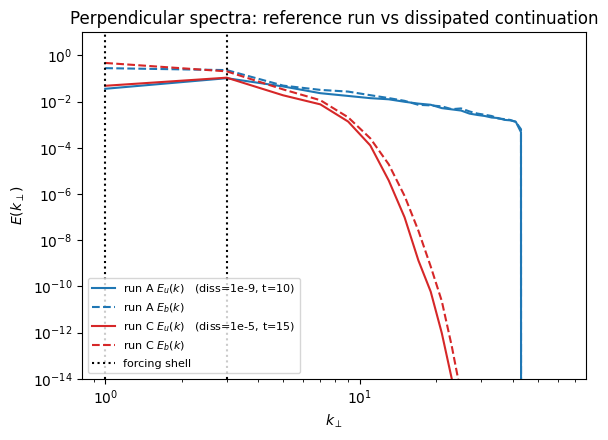

In [9]:
bins_a, su_a, sb_a = diag.perpspec(end_a, kgrid_a, params_a)
bins_c, su_c, sb_c = diag.perpspec(end_c, kgrid_c, params_c)

plt.figure(figsize=(6.5, 4.5))
plt.loglog(bins_a, su_a, 'C0', label=r'run A $E_u(k)$   (diss=1e-9, t=10)')
plt.loglog(bins_a, sb_a, 'C0--', label=r'run A $E_b(k)$')
plt.loglog(bins_c, su_c, 'C3', label=r'run C $E_u(k)$   (diss=1e-5, t=15)')
plt.loglog(bins_c, sb_c, 'C3--', label=r'run C $E_b(k)$')
kunit = min(2 * jnp.pi / params_a.Lx, 2 * jnp.pi / params_a.Ly)
plt.axvline(params_a.fshell[0] * kunit, color='k', linestyle=':', label='forcing shell')
plt.axvline(params_a.fshell[1] * kunit, color='k', linestyle=':')
plt.xlabel(r'$k_\perp$')
plt.ylabel(r'$E(k_\perp)$')
plt.ylim(1e-14, 10)
plt.legend(fontsize=8)
plt.title("Perpendicular spectra: reference run vs dissipated continuation")

### 6. Checkpointing invariants worth knowing

From `docs/checkpointing.md` (read it before touching `snapshot_io.py`):

- **Reads never construct a `CheckpointManager`** -- `load_snapshot` handles it with a
  bare, barrier-free `StandardCheckpointHandler`. Manager restores synchronize across
  processes and deadlock as soon as ranks read different directories.
- **Enumerate saved steps with `sn.get_saved_steps(snap_path)`**, never
  `mngr.all_steps()`: a top-level manager over a per-rank (MPI) layout misreads rank
  subfolders as step numbers.
- **Snapshots restore across rank layouts** (save on $N$ ranks, restore on $M$):
  `load_snapshot` unions overlapping z-slices per rank. Not demonstrable in this
  single-process notebook -- see the resharding section of the doc and
  `tests/test_restart_resharding.py`.
- **`simulate`/`simulate_scan` overshoot**: the loop steps until $t \ge$ target, so a
  run can overshoot `t_snap` or `t_end` by up to one step (`cfl_every` steps when
  stepping in blocks). Snapshots are "at least `t_snap` apart" and the end time is
  "$\ge$ `t_end`" -- never assume exact snapshot counts or end times in
  postprocessing (this notebook always used `get_saved_steps` and `steps[-1]` instead
  of hard-coding indices).
- **`forcing_scale` is always a concrete `(n_ou,)` array** in any saved/loaded state
  (zeros when forcing is off, never `None`), so every checkpoint shares one on-disk tree
  structure.
- Old (pre-`forcing_scale`) snapshot directories fail to restore with a structure
  mismatch; upgrade them once, in place, with
  `snapshot_io.old_snapshot_repair(snap_path, params)`.